## 单语言 定位单个关键head

Layer 0 Head 0 → -0.3566
Layer 0 Head 1 → 0.1725
Layer 0 Head 2 → -0.6161
Layer 0 Head 3 → 0.2747
Layer 0 Head 4 → 0.5676
Layer 0 Head 5 → -0.4420
Layer 0 Head 6 → -0.0107
Layer 0 Head 7 → -0.2471
Layer 0 Head 8 → -2.3913
Layer 0 Head 9 → -0.0932
Layer 0 Head 10 → 0.0198
Layer 0 Head 11 → -0.7781
Layer 1 Head 0 → -0.5019
Layer 1 Head 1 → -0.5262
Layer 1 Head 2 → 0.0116
Layer 1 Head 3 → -1.2860
Layer 1 Head 4 → -1.0178
Layer 1 Head 5 → -0.0525
Layer 1 Head 6 → -0.0041
Layer 1 Head 7 → -0.8598
Layer 1 Head 8 → -3.0342
Layer 1 Head 9 → -0.3542
Layer 1 Head 10 → -0.1965
Layer 1 Head 11 → -0.0471
Layer 2 Head 0 → 0.3769
Layer 2 Head 1 → -0.1011
Layer 2 Head 2 → -0.3962
Layer 2 Head 3 → 0.0461
Layer 2 Head 4 → -0.8034
Layer 2 Head 5 → -1.3813
Layer 2 Head 6 → -0.1322
Layer 2 Head 7 → -0.3057
Layer 2 Head 8 → -0.0150
Layer 2 Head 9 → -0.6230
Layer 2 Head 10 → -0.0000
Layer 2 Head 11 → 0.0079
Layer 3 Head 0 → 0.0328
Layer 3 Head 1 → -0.2847
Layer 3 Head 2 → 0.1998
Layer 3 Head 3 → -0.0889
Laye

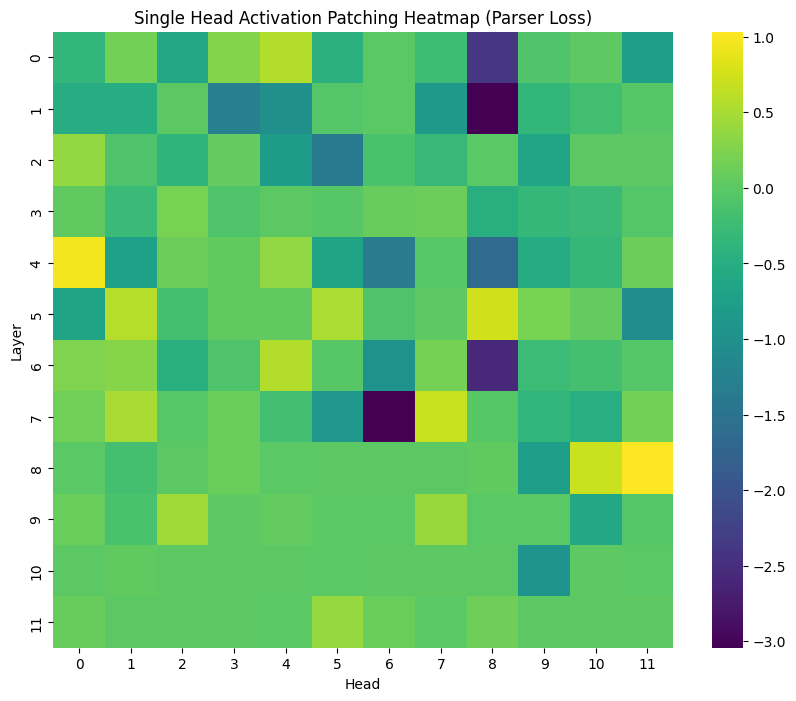

In [16]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from transformers import AutoModel, AutoTokenizer

# =========================
# 1️⃣ 设置 device & checkpoint
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint_path = "/mnt/ssd/weicheng/data_interns/yahan/syntactic-parsing/models/last4_en/best_model.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)

args = checkpoint["args"]

# =========================
# 2️⃣ 导入 Parser 类和 mask 函数
# =========================
# 这里假设 train_parser.py 在 src/ 下
import sys
sys.path.append("/mnt/ssd3/weicheng/data_interns/yahan/workplace/syntactic-parsing/src")

from train_parser import BiaffineDependencyParser, mask_arc_scores

# =========================
# 3️⃣ 初始化 encoder & parser model
# =========================
encoder = AutoModel.from_pretrained(args["model_name"])

# 确保 num_labels 和 checkpoint 一致
num_labels = checkpoint.get("num_labels", None)
if num_labels is None:
    num_labels = checkpoint["model_state_dict"]["rel_biaffine.weight"].shape[0]

model = BiaffineDependencyParser(
    encoder=encoder,
    num_labels=num_labels,
    hidden_size=encoder.config.hidden_size,
    mlp_size=args["mlp_size"],
    dropout=args["dropout"],
)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

# =========================
# 4️⃣ 构造 clean / corrupted 输入
# =========================
tokenizer = AutoTokenizer.from_pretrained(args["model_name"])

clean_text = "I read the book."
corrupted_text = "book the read I."

clean_inputs = tokenizer(clean_text, return_tensors="pt").to(device)
corr_inputs = tokenizer(corrupted_text, return_tensors="pt").to(device)

# =========================
# 5️⃣ 定义 metric: parser loss
# =========================
def parser_loss_metric(outputs, input_ids, attention_mask):
    """
    使用 parser 的 arc+rel loss 作为 metric
    """
    arc_scores, rel_scores = outputs
    # 使用 mask: 所有非 padding token
    mask = attention_mask.bool()
    
    # 这里用 argmax 模拟 gold，真实情况如果有 gold heads/labels，直接传进去计算 loss
    # 如果只是分析 head patching 方向，这里可以用 logit 差或类似指标
    loss_fn = nn.CrossEntropyLoss(reduction="none")
    
    # Arc loss: 使用 self heads (placeholder)
    batch_size, seq_len, _ = arc_scores.shape
    pred_heads = arc_scores.argmax(dim=-1)
    arc_loss = loss_fn(arc_scores.view(-1, arc_scores.size(-1)), pred_heads.view(-1))
    arc_loss = (arc_loss * mask.view(-1).float()).sum() / mask.sum()
    
    # Rel loss: 同样用 pred_heads 当 gold
    batch_indices = torch.arange(batch_size, device=device).unsqueeze(1).expand(-1, seq_len)
    token_indices = torch.arange(seq_len, device=device).unsqueeze(0).expand(batch_size, -1)
    rel_scores_at_heads = rel_scores[batch_indices, token_indices, pred_heads]
    rel_pred_labels = rel_scores_at_heads.argmax(dim=-1)
    rel_loss = loss_fn(rel_scores_at_heads.view(-1, rel_scores_at_heads.size(-1)),
                       rel_pred_labels.view(-1))
    rel_loss = (rel_loss * mask.view(-1).float()).sum() / mask.sum()
    
    return (arc_loss + rel_loss).item()

# =========================
# 6️⃣ 获取所有 layer 输出
# =========================
def get_activations(model, input_ids, attention_mask):
    activations = {}

    def save_hook(name):
        def hook(module, input, output):
            if isinstance(output, tuple):
                activations[name] = output[0].detach()
            else:
                activations[name] = output.detach()
        return hook

    handles = []
    for i, layer in enumerate(model.encoder.encoder.layer):
        handle = layer.attention.self.register_forward_hook(save_hook(f"layer_{i}"))
        handles.append(handle)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

    for h in handles:
        h.remove()

    return outputs, activations

# =========================
# 7️⃣ 单个 head patch
# =========================
def patch_single_head(model, clean_acts, corrupted_input_ids, corrupted_attention_mask, layer_idx, head_idx):
    def patch_hook(module, input, output):
        if isinstance(output, tuple):
            context_layer = output[0]
            rest = output[1:]
        else:
            context_layer = output
            rest = ()
        batch, seq_len, hidden = context_layer.shape
        num_heads = module.num_attention_heads
        head_dim = hidden // num_heads

        output_heads = context_layer.view(batch, seq_len, num_heads, head_dim)
        clean_heads = clean_acts[f"layer_{layer_idx}"].view(batch, seq_len, num_heads, head_dim)

        output_heads[:, :, head_idx, :] = clean_heads[:, :, head_idx, :]
        patched = output_heads.view(batch, seq_len, hidden)

        if isinstance(output, tuple):
            return (patched,) + rest
        else:
            return patched

    handle = model.encoder.encoder.layer[layer_idx].attention.self.register_forward_hook(patch_hook)
    with torch.no_grad():
        outputs = model(corrupted_input_ids, attention_mask=corrupted_attention_mask)
    handle.remove()
    return outputs

# =========================
# 8️⃣ Circuit discovery
# =========================
# Baseline / Upper bound
baseline_out = model(**corr_inputs)
clean_out = model(**clean_inputs)

baseline_score = parser_loss_metric(baseline_out, **corr_inputs)
clean_score = parser_loss_metric(clean_out, **clean_inputs)

_, clean_acts = get_activations(model, **clean_inputs)

n_layers = model.encoder.config.num_hidden_layers
n_heads = model.encoder.config.num_attention_heads
heatmap = np.zeros((n_layers, n_heads))

for l in range(n_layers):
    for h in range(n_heads):
        patched_out = patch_single_head(
            model, clean_acts,
            corr_inputs["input_ids"], corr_inputs["attention_mask"],
            l, h
        )
        patched_score = parser_loss_metric(patched_out, **corr_inputs)
        # improvement: loss 减少越多越好
        improvement = (baseline_score - patched_score) / (baseline_score - clean_score + 1e-8)
        heatmap[l, h] = improvement
        print(f"Layer {l} Head {h} → {improvement:.4f}")

# =========================
# 9️⃣ 画热力图
# =========================
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap, cmap="viridis")
plt.xlabel("Head")
plt.ylabel("Layer")
plt.title("Single Head Activation Patching Heatmap (Parser Loss)")
plt.show()


## 单语言 定位关键head patch

In [17]:
# =========================
# 10️⃣ Top-k / threshold head selection
# =========================
top_k = 10        # 选择 improvement 最大的前 top_k 个 head
threshold = 0.3 # 或选择 improvement >= 阈值的 head

# Flatten heatmap并获取对应的 layer/head idx
layer_idx, head_idx = np.meshgrid(np.arange(n_layers), np.arange(n_heads), indexing='ij')
layer_idx = layer_idx.flatten()
head_idx = head_idx.flatten()
improvement_flat = heatmap.flatten()

# 根据 top_k
top_indices = np.argsort(improvement_flat)[-top_k:][::-1]
top_heads = [(int(layer_idx[i]), int(head_idx[i]), improvement_flat[i]) for i in top_indices]
print("Top-k heads by improvement:")
for l, h, imp in top_heads:
    print(f"Layer {l} Head {h} → improvement {imp:.4f}")

# 根据阈值
threshold_heads = [(int(layer_idx[i]), int(head_idx[i]), improvement_flat[i])
                   for i in range(len(improvement_flat)) if improvement_flat[i] >= threshold]
print("\nHeads above threshold:")
for l, h, imp in threshold_heads:
    print(f"Layer {l} Head {h} → improvement {imp:.4f}")


Top-k heads by improvement:
Layer 8 Head 11 → improvement 1.0332
Layer 4 Head 0 → improvement 0.9615
Layer 5 Head 8 → improvement 0.7387
Layer 8 Head 10 → improvement 0.7001
Layer 7 Head 7 → improvement 0.6874
Layer 5 Head 1 → improvement 0.5825
Layer 0 Head 4 → improvement 0.5676
Layer 6 Head 4 → improvement 0.5640
Layer 5 Head 5 → improvement 0.5094
Layer 7 Head 1 → improvement 0.4957

Heads above threshold:
Layer 0 Head 4 → improvement 0.5676
Layer 2 Head 0 → improvement 0.3769
Layer 4 Head 0 → improvement 0.9615
Layer 4 Head 4 → improvement 0.3582
Layer 5 Head 1 → improvement 0.5825
Layer 5 Head 5 → improvement 0.5094
Layer 5 Head 8 → improvement 0.7387
Layer 6 Head 4 → improvement 0.5640
Layer 7 Head 1 → improvement 0.4957
Layer 7 Head 7 → improvement 0.6874
Layer 8 Head 10 → improvement 0.7001
Layer 8 Head 11 → improvement 1.0332
Layer 9 Head 2 → improvement 0.4585
Layer 9 Head 7 → improvement 0.4118
Layer 11 Head 5 → improvement 0.3915


In [18]:
from itertools import combinations

def patch_multiple_heads(model, clean_acts, input_ids, attention_mask, heads_to_patch):
    """
    heads_to_patch: [(layer_idx, head_idx), ...]
    """
    # 按层分组
    layer2heads = {}
    for l, h in heads_to_patch:
        layer2heads.setdefault(l, []).append(h)

    hooks = []

    # 注册 hook
    for layer_idx, head_list in layer2heads.items():
        module = model.encoder.encoder.layer[layer_idx].attention.self


        def make_patch_hook(layer_head_list):
            def patch_hook(module, input, output):
                if isinstance(output, tuple):
                    context_layer = output[0]
                    rest = output[1:]
                else:
                    context_layer = output
                    rest = ()

                batch, seq_len, hidden = context_layer.shape
                num_heads = module.num_attention_heads
                head_dim = hidden // num_heads

                output_heads = context_layer.view(batch, seq_len, num_heads, head_dim)

                # patch 指定 head
                clean_layer = clean_acts[f"layer_{layer_idx}"]
                clean_heads_tensor = clean_layer.view(batch, seq_len, num_heads, head_dim)
                for h_idx in layer_head_list:
                    output_heads[:, :, h_idx, :] = clean_heads_tensor[:, :, h_idx, :]

                patched = output_heads.view(batch, seq_len, hidden)

                if isinstance(output, tuple):
                    return (patched,) + rest
                else:
                    return patched

            return patch_hook

        hook = module.register_forward_hook(make_patch_hook(head_list))
        hooks.append(hook)

    # forward
    out = model(input_ids=input_ids, attention_mask=attention_mask)

    # 移除 hook
    for h in hooks:
        h.remove()

    return out


In [19]:
from itertools import combinations

# =========================
# 12️⃣ 测试组合回路（按 improvement 排序）
# =========================

# 使用 top_heads 或 threshold_heads
candidate_heads = [(l, h) for l, h, imp in top_heads]

baseline_out = model(**corr_inputs)
baseline_score = parser_loss_metric(baseline_out, **corr_inputs)

results = []  # 存储每个组合的 improvement

# 可以先从单 head 开始，再尝试组合
for k in range(1, min(10, len(candidate_heads)+1)):  # 测试组合长度 1~3
    for comb in combinations(candidate_heads, k):
        patched_out = patch_multiple_heads(
            model, clean_acts,
            corr_inputs["input_ids"],
            corr_inputs["attention_mask"],
            comb
        )
        patched_score = parser_loss_metric(patched_out, **corr_inputs)
        improvement = (baseline_score - patched_score) / \
                      (baseline_score - parser_loss_metric(clean_out, **clean_inputs) + 1e-8)
        results.append((comb, improvement))

# 按 improvement 从高到低排序
results.sort(key=lambda x: x[1], reverse=True)

# 打印排序结果
for comb, improvement in results:
    print(f"Patching heads {comb} → improvement: {improvement:.4f}")


Patching heads ((0, 4), (6, 4), (5, 5), (7, 1)) → improvement: 2.1155
Patching heads ((7, 7), (5, 1), (5, 5)) → improvement: 2.0677
Patching heads ((0, 4), (5, 5), (7, 1)) → improvement: 1.8885
Patching heads ((4, 0), (0, 4), (6, 4), (5, 5), (7, 1)) → improvement: 1.7917
Patching heads ((7, 7), (5, 1), (7, 1)) → improvement: 1.7827
Patching heads ((6, 4), (5, 5), (7, 1)) → improvement: 1.7671
Patching heads ((7, 7), (6, 4), (5, 5)) → improvement: 1.7581
Patching heads ((7, 7), (5, 1)) → improvement: 1.7558
Patching heads ((4, 0), (7, 7), (5, 1), (5, 5)) → improvement: 1.7286
Patching heads ((7, 7), (5, 1), (5, 5), (7, 1)) → improvement: 1.7230
Patching heads ((4, 0), (7, 7), (5, 1)) → improvement: 1.6810
Patching heads ((8, 11), (7, 7), (5, 1), (5, 5)) → improvement: 1.6751
Patching heads ((4, 0), (7, 7), (0, 4), (6, 4), (5, 5)) → improvement: 1.6369
Patching heads ((4, 0), (0, 4), (5, 5), (7, 1)) → improvement: 1.6279
Patching heads ((4, 0), (7, 7), (0, 4), (5, 5)) → improvement: 1.59

## 跨语言 

Baseline Loss: 0.9552, Upper Bound Loss: 0.5746


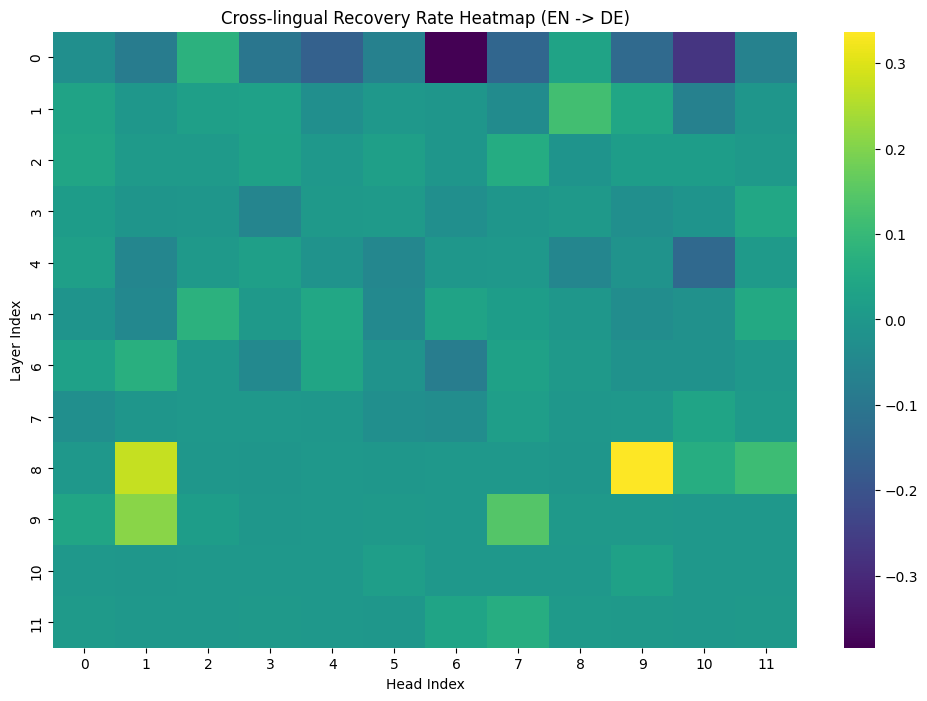


Top-k heads by improvement:
Layer 8 Head 9 → improvement 0.3370
Layer 8 Head 1 → improvement 0.2730
Layer 9 Head 1 → improvement 0.2101
Layer 9 Head 7 → improvement 0.1448
Layer 1 Head 8 → improvement 0.1190
Patching heads ((8, 9), (8, 1), (9, 1), (9, 7), (1, 8), (8, 11), (0, 2), (5, 2), (6, 1), (8, 10)) → improvement: 0.6744
Patching heads ((8, 9), (8, 1), (9, 1), (9, 7), (1, 8), (8, 11), (0, 2), (5, 2), (6, 1)) → improvement: 0.6575
Patching heads ((8, 1), (9, 1), (9, 7), (1, 8), (8, 11), (0, 2), (5, 2), (6, 1), (8, 10)) → improvement: 0.6120


In [10]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "5"  # 指定使用 GPU 5
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoModel, AutoTokenizer
from itertools import combinations
import sys

# 确保你的模块路径正确
sys.path.append("/mnt/ssd3/weicheng/data_interns/yahan/workplace/syntactic-parsing/src")
from train_parser import BiaffineDependencyParser

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# 1️⃣ 初始化模型函数
# =========================
def init_model(checkpoint_path, device):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    args = checkpoint["args"]
    encoder = AutoModel.from_pretrained(args["model_name"])
    
    # 从权重中动态获取 label 数量
    num_labels = checkpoint["model_state_dict"]["rel_biaffine.weight"].shape[0]
    
    model = BiaffineDependencyParser(
        encoder=encoder,
        num_labels=num_labels,
        hidden_size=encoder.config.hidden_size,
        mlp_size=args["mlp_size"],
        dropout=args["dropout"],
    )
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)
    model.eval()
    return model, args

# 加载你的两个模型状态
path_en = "/mnt/ssd/weicheng/data_interns/yahan/syntactic-parsing/models/last4_en/best_model.pt"
path_de = "/mnt/ssd/weicheng/data_interns/yahan/syntactic-parsing/models/last4_en2de/best_model.pt"

model_s, args_en = init_model(path_en, device) # Source 专家
model_t, args_de = init_model(path_de, device) # Target 学生

tokenizer = AutoTokenizer.from_pretrained(args_en["model_name"])

# =========================
# 2️⃣ 完善 Loss 计算函数 (修复 NameError)
# =========================
def parser_loss_metric(outputs, input_ids, attention_mask):
    arc_scores, rel_scores = outputs
    mask = attention_mask.bool()
    batch_size, seq_len, _ = arc_scores.shape
    
    # 预测 heads 用于计算针对当前状态的 loss
    pred_heads = arc_scores.argmax(dim=-1)

    loss_fn = nn.CrossEntropyLoss(reduction="none")
    
    # Arc Loss
    arc_loss = loss_fn(arc_scores.view(-1, arc_scores.size(-1)), pred_heads.view(-1))
    arc_loss = (arc_loss * mask.view(-1).float()).sum() / (mask.sum() + 1e-8)

    # Rel Loss
    batch_indices = torch.arange(batch_size, device=device).unsqueeze(1).expand(-1, seq_len)
    token_indices = torch.arange(seq_len, device=device).unsqueeze(0).expand(batch_size, -1)
    rel_scores_at_heads = rel_scores[batch_indices, token_indices, pred_heads]
    
    rel_pred_labels = rel_scores_at_heads.argmax(dim=-1)
    rel_loss = loss_fn(rel_scores_at_heads.view(-1, rel_scores_at_heads.size(-1)), rel_pred_labels.view(-1))
    rel_loss = (rel_loss * mask.view(-1).float()).sum() / (mask.sum() + 1e-8)
    
    return (arc_loss + rel_loss).item()

# =========================
# 3️⃣ 数据与对齐准备
# =========================
# 对齐字典: En(read:2) -> De(lese:3) 等
token_mapping = {0:0, 1:4, 2:3, 4:1, 5:5, 6:6}

text_en = "I read the book."
text_de_corr = "Buch das lese ich." 
text_de_clean = "Ich lese das Buch."

inputs_en = tokenizer(text_en, return_tensors="pt").to(device)
inputs_de_corr = tokenizer(text_de_corr, return_tensors="pt").to(device)
inputs_de_clean = tokenizer(text_de_clean, return_tensors="pt").to(device)

# =========================
# 4️⃣ 激活值抓取与 Patch 钩子
# =========================
def get_source_activations(model, inputs):
    cache = {}
    def hook_fn(name):
        def hook(module, input, output):
            cache[name] = output[0].detach() if isinstance(output, tuple) else output.detach()
        return hook

    handles = []
    for i, layer in enumerate(model.encoder.encoder.layer):
        h = layer.attention.self.register_forward_hook(hook_fn(f"layer_{i}"))
        handles.append(h)
    
    with torch.no_grad():
        model(**inputs)
    for h in handles: h.remove()
    return cache

clean_acts_en = get_source_activations(model_s, inputs_en)

def patch_cross_lingual_hook(module, input, output, layer_idx, head_idx, src_cache, mapping):
    if isinstance(output, tuple):
        context_layer, rest = output[0], output[1:]
    else:
        context_layer, rest = output, ()

    batch, seq_len, hidden = context_layer.shape
    num_heads = module.num_attention_heads
    head_dim = hidden // num_heads

    tgt_act = context_layer.view(batch, seq_len, num_heads, head_dim)
    src_act = src_cache[f"layer_{layer_idx}"].view(batch, -1, num_heads, head_dim)

    # 按照 mapping 搬运
    for src_pos, tgt_pos in mapping.items():
        if src_pos < src_act.size(1) and tgt_pos < tgt_act.size(1):
            tgt_act[:, tgt_pos, head_idx, :] = src_act[:, src_pos, head_idx, :]
    
    patched_output = tgt_act.reshape(batch, seq_len, hidden)
    return (patched_output,) + rest if rest else patched_output

# =========================
# 5️⃣ 运行热力图扫描
# =========================
n_layers = model_s.encoder.config.num_hidden_layers
n_heads = model_s.encoder.config.num_attention_heads
heatmap = np.zeros((n_layers, n_heads))

with torch.no_grad():
    base_out = model_t(**inputs_de_corr)
    upper_out = model_t(**inputs_de_clean)
    
baseline_score = parser_loss_metric(base_out, **inputs_de_corr)
upper_score = parser_loss_metric(upper_out, **inputs_de_clean)

print(f"Baseline Loss: {baseline_score:.4f}, Upper Bound Loss: {upper_score:.4f}")

for l in range(n_layers):
    for h in range(n_heads):
        # 局部作用域绑定 l 和 h
        def make_hook(l_idx, h_idx):
            return lambda m, i, o: patch_cross_lingual_hook(m, i, o, l_idx, h_idx, clean_acts_en, token_mapping)
        
        handle = model_t.encoder.encoder.layer[l].attention.self.register_forward_hook(make_hook(l, h))
        
        with torch.no_grad():
            patched_out = model_t(**inputs_de_corr)
        handle.remove()

        patched_score = parser_loss_metric(patched_out, **inputs_de_corr)
        
        # 恢复率：(Base - Patch) / (Base - Upper)
        recovery = (baseline_score - patched_score) / (baseline_score - upper_score + 1e-8)
        heatmap[l, h] = recovery
        # 保存原始 improvement（不截断）
        if 'head_improvements' not in globals():
            head_improvements = {}
        head_improvements[(l, h)] = recovery



# =========================
# 6️⃣ 可视化
# =========================
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap, annot=False, cmap="viridis")
plt.title("Cross-lingual Recovery Rate Heatmap (EN -> DE)")
plt.xlabel("Head Index")
plt.ylabel("Layer Index")
plt.show()


# =========================
# 7️⃣ 打印 Top-k heads
# =========================

print("\nTop-k heads by improvement:")

# 排序（从大到小）
sorted_heads = sorted(head_improvements.items(), key=lambda x: x[1], reverse=True)

top_k = 5
for (layer, head), score in sorted_heads[:top_k]:
    print(f"Layer {layer} Head {head} → improvement {score:.4f}")

# =========================
# 8️⃣ 多头联合 patch 测试
# =========================

def multi_patch(head_list):
    handles = []
    for (l, h) in head_list:
        handle = model_t.encoder.encoder.layer[l].attention.self.register_forward_hook(
            make_hook(l, h)
        )
        handles.append(handle)

    with torch.no_grad():
        patched_out = model_t(**inputs_de_corr)

    for hndl in handles:
        hndl.remove()

    patched_score = parser_loss_metric(patched_out, **inputs_de_corr)
    recovery = (baseline_score - patched_score) / (baseline_score - upper_score + 1e-8)
    return recovery


# 取前 10 个 head 做组合测试
top_heads_only = [x[0] for x in sorted_heads[:10]]

# 测试几个组合（举例）
test_combos = [
    tuple(top_heads_only),
    tuple(top_heads_only[:-1]),
    tuple(top_heads_only[1:])
]

for combo in test_combos:
    score = multi_patch(combo)
    print(f"Patching heads {combo} → improvement: {score:.4f}")